In [ ]:
import os
import tensorflow as tf
import numpy as np
import cv2



In [ ]:
# Listcontents
dataset_path = '/kaggle/input/plant-seg-unet/dataset'
print(os.listdir(dataset_path))

images_path = os.path.join(dataset_path, 'images')
annotations_path = os.path.join(dataset_path, 'annotations')

# images and annotations
print("Images Folder:", os.listdir(images_path))
print("Annotations Folder:", os.listdir(annotations_path))



['annotations', 'images']
Images Folder: ['val', 'test', 'train']
Annotations Folder: ['val', 'test', 'train']


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

#paths
images_train_path = os.path.join(dataset_path, 'images', 'train')
annotations_train_path = os.path.join(dataset_path, 'annotations', 'train')

# List files in the images and annotations folder
image_files = sorted(os.listdir(images_train_path))
mask_files = sorted(os.listdir(annotations_train_path))



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# augmentation
seed = 42
image_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

mask_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [ ]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, mask_paths, batch_size, image_size=(256, 256), shuffle=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.image_size = image_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        #batch indices
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        image_paths_batch = [self.image_paths[k] for k in batch_indexes]
        mask_paths_batch = [self.mask_paths[k] for k in batch_indexes]

        # batch images and masks
        images = np.array([self.load_image(img_path) for img_path in image_paths_batch])
        masks = np.array([self.load_mask(mask_path) for mask_path in mask_paths_batch])

        return images, masks

    def load_image(self, image_path):
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.image_size)
        return img / 255.0

    def load_mask(self, mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.image_size)
        mask = np.expand_dims(mask, axis=-1)  # extra dimension for the channel
        return mask / 255.0

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Activation
from tensorflow.keras.models import Model

def conv_block(input_tensor, num_filters):
    x = Conv2D(num_filters, kernel_size=(3, 3), padding="same")(input_tensor)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.3)(x)

    x = Conv2D(num_filters, kernel_size=(3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

def encoder_block(input_tensor, num_filters):
    x = conv_block(input_tensor, num_filters)
    p = MaxPooling2D(pool_size=(2, 2))(x)
    return x, p

def decoder_block(input_tensor, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, kernel_size=(2, 2), strides=(2, 2), padding="same")(input_tensor)
    x = concatenate([x, skip_features])
    x = conv_block(x, num_filters)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(shape=input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder Path
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(filters=1, kernel_size=(1, 1), padding="same", activation="sigmoid")(d4)

    model = Model(inputs, outputs, name="U-Net")
    return model


input_shape = (256, 256, 3)
unet_model = build_unet(input_shape=input_shape)
# unet_model.compile(
#     optimizer="adam",
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )
# unet_model.summary()


In [ ]:
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam



def dice_coefficient(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    y_true_f = K.cast(y_true_f, 'float32')
    y_pred_f = K.cast(y_pred_f, 'float32')

    intersection = K.sum(y_true_f * y_pred_f)
    return (2 * intersection + 1e-7) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1e-7)




def pixel_accuracy(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')

    y_pred = K.round(y_pred)
    correct = K.sum(K.cast(K.equal(y_true, y_pred), 'float32'))
    total = K.prod(K.cast(K.shape(y_true), 'float32'))
    return correct / total


def dice_loss(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2 * intersection + 1e-7) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1e-7)


def iou_score(y_true, y_pred, threshold=0.5):

    y_pred = tf.cast(y_pred > threshold, tf.float32)
    y_true = tf.cast(y_true, tf.float32)


    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection


    iou = (intersection + 1e-7) / (union + 1e-7)
    return iou


unet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=dice_loss,
    metrics=[dice_coefficient, iou_score, pixel_accuracy]
)

unet_model.summary()





Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 256, 256, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 256, 256, 64)   │              0 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 64)   │         36,928 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 256, 256, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 64)   │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128, 128, 128)  │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 128, 128, 128)  │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128, 128, 128)  │              0 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 128)  │        147,584 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 128)  │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 128, 128, 128)  │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 128)    │              0 │ activation_3[0][0]     │
│ (MaxPooling2D)       

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [ ]:
images_val_path = os.path.join(dataset_path, 'images', 'val')
annotations_val_path = os.path.join(dataset_path, 'annotations', 'val')



image_files_val = sorted(os.listdir(images_val_path))
mask_files_val = sorted(os.listdir(annotations_val_path))

batch_size = 16

train_generator = DataGenerator(
    image_paths=[os.path.join(images_train_path, f) for f in image_files],
    mask_paths=[os.path.join(annotations_train_path, f) for f in mask_files],
    batch_size=batch_size,
    image_size=(256, 256)
)


val_generator = DataGenerator(
    image_paths=[os.path.join(images_val_path, f) for f in image_files_val],
    mask_paths=[os.path.join(annotations_val_path, f) for f in mask_files_val],
    batch_size=batch_size,
    image_size=(256, 256)
)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
callbacks = [
    ModelCheckpoint("unet_best_model.keras", save_best_only=True, monitor="val_loss"),
    EarlyStopping(patience=3, monitor="val_loss"),
    ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6)
]

history = unet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=callbacks
)



Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


494/494 ━━━━━━━━━━━━━━━━━━━━ 274s 443ms/step - dice_coefficient: 0.1576 - iou_score: 0.0906 - loss: 0.8424 - pixel_accuracy: 0.5364 - val_dice_coefficient: 0.0601 - val_iou_score: 0.0205 - val_loss: 0.9399 - val_pixel_accuracy: 0.7871 - learning_rate: 1.0000e-04
Epoch 2/25
494/494 ━━━━━━━━━━━━━━━━━━━━ 210s 422ms/step - dice_coefficient: 0.2017 - iou_score: 0.1166 - loss: 0.7983 - pixel_accuracy: 0.6627 - val_dice_coefficient: 0.2017 - val_iou_score: 0.1174 - val_loss: 0.7983 - val_pixel_accuracy: 0.7643 - learning_rate: 1.0000e-04
Epoch 3/25
494/494 ━━━━━━━━━━━━━━━━━━━━ 211s 423ms/step - dice_coefficient: 0.2201 - iou_score: 0.1277 - loss: 0.7799 - pixel_accuracy: 0.7022 - val_dice_coefficient: 0.2172 - val_iou_score: 0.1246 - val_loss: 0.7828 - val_pixel_accuracy: 0.7459 - learning_rate: 1.0000e-04
Epoch 4/25
494/494 ━━━━━━━━━━━━━━━━━━━━ 210s 421ms/step - dice_coefficient: 0.2327 - iou_score: 0.1347 - loss: 0.7673 - pixel_accuracy: 0.7144 - val_dice_coefficient: 0.2174 - val_iou_score

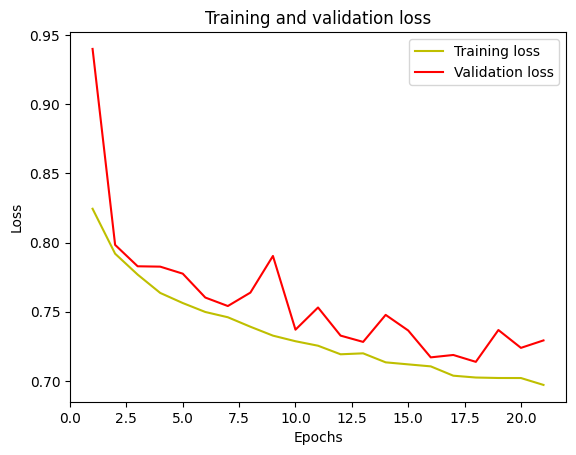

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



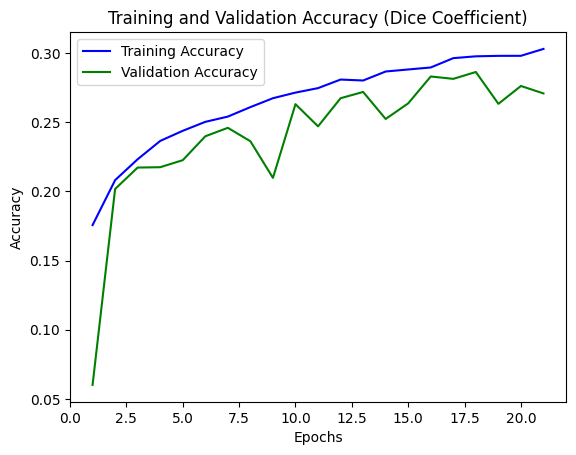

In [ ]:
accuracy = history.history['dice_coefficient']
val_accuracy = history.history['val_dice_coefficient']

epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'g', label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Dice Coefficient)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Define test image paths (assuming the test set is organized similarly to train and validation)
# images_test_path = os.path.join(dataset_path, 'images', 'test')
# annotations_test_path = os.path.join(dataset_path, 'annotations', 'test')

# # List files in the test images and annotations folder
# image_files_test = sorted(os.listdir(images_test_path))
# mask_files_test = sorted(os.listdir(annotations_test_path))

# # Test Data Generator
# test_generator = DataGenerator(
#     image_paths=[os.path.join(images_test_path, f) for f in image_files_test],
#     mask_paths=[os.path.join(annotations_test_path, f) for f in mask_files_test],
#     batch_size=batch_size,
#     image_size=(256, 256)
# )


In [ ]:
# import os

# # Define dataset path (update the name as per your uploaded dataset)
# dataset_path = '../input/your-username-test-images'

# # Define test image paths
# images_test_path = os.path.join(dataset_path, 'images', 'test')
# annotations_test_path = os.path.join(dataset_path, 'annotations', 'test')

# image_files_test = sorted(os.listdir(images_test_path))
# mask_files_test = sorted(os.listdir(annotations_test_path))


# test_generator = DataGenerator(
#     image_paths=[os.path.join(images_test_path, f) for f in image_files_test],
#     mask_paths=[os.path.join(annotations_test_path, f) for f in mask_files_test],
#     batch_size=batch_size,  # Set your desired batch size
#     image_size=(256, 256)  # Set your image size
# )

# # Verify paths and files
# print(f"Number of test images: {len(image_files_test)}")
# print(f"Number of test masks: {len(mask_files_test)}")
# print(f"First test image path: {os.path.join(images_test_path, image_files_test[0])}")
# print(f"First test mask path: {os.path.join(annotations_test_path, mask_files_test[0])}")


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

images_test_path = os.path.join(dataset_path, 'images', 'test')
annotations_test_path = os.path.join(dataset_path, 'annotations', 'test')


image_files = sorted(os.listdir(images_test_path))
mask_files = sorted(os.listdir(annotations_test_path))

In [ ]:
test_generator = DataGenerator(
    image_paths=[os.path.join(images_test_path, f) for f in image_files],
    mask_paths=[os.path.join(annotations_test_path, f) for f in mask_files],
    batch_size=batch_size,
    image_size=(256, 256)
)

In [ ]:

def evaluate_model_on_set(model, generator, set_name="Dataset"):

    print(f"Evaluating on {set_name}...")


    results = model.evaluate(generator, verbose=1)
    metrics = {metric_name: metric_value for metric_name, metric_value in zip(model.metrics_names, results)}


    print(f"Results on {set_name}:")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

    return metrics


train_metrics = evaluate_model_on_set(unet_model, train_generator, set_name="Training Set")
val_metrics = evaluate_model_on_set(unet_model, val_generator, set_name="Validation Set")
test_metrics = evaluate_model_on_set(unet_model, test_generator, set_name="Test Set")


print("\nSummary of Evaluation Results:")
print(f"{'Metric':<20} {'Train':<10} {'Validation':<10} {'Test':<10}")
for metric_name in unet_model.metrics_names:
    train_val = train_metrics.get(metric_name, '-')
    val_val = val_metrics.get(metric_name, '-')
    test_val = test_metrics.get(metric_name, '-')
    print(f"{metric_name:<20} {train_val:<10.4f} {val_val:<10.4f} {test_val:<10.4f}")


Evaluating on Training Set...
494/494 ━━━━━━━━━━━━━━━━━━━━ 103s 208ms/step - dice_coefficient: 0.2843 - iou_score: 0.1672 - loss: 0.7157 - pixel_accuracy: 0.7660
Results on Training Set:
loss: 0.7183
compile_metrics: 0.2817
Evaluating on Validation Set...
77/77 ━━━━━━━━━━━━━━━━━━━━ 15s 198ms/step - dice_coefficient: 0.2682 - iou_score: 0.1562 - loss: 0.7318 - pixel_accuracy: 0.7804
Results on Validation Set:
loss: 0.7293
compile_metrics: 0.2707
Evaluating on Test Set...
143/143 ━━━━━━━━━━━━━━━━━━━━ 55s 385ms/step - dice_coefficient: 0.2605 - iou_score: 0.1511 - loss: 0.7395 - pixel_accuracy: 0.7761
Results on Test Set:
loss: 0.7344
compile_metrics: 0.2656

Summary of Evaluation Results:
Metric               Train      Validation Test      
loss                 0.7183     0.7293     0.7344    
compile_metrics      0.2817     0.2707     0.2656    


In [ ]:
import os
os.makedirs('models', exist_ok=True)

unet_model.save("unet_model.h5")


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/unet_best_model.keras", compile=False)


In [ ]:
# from tensorflow.keras.preprocessing.image import load_img, img_to_array
# import numpy as np


# test_image_paths = ["path_to_image1.jpg", "path_to_image2.jpg", "path_to_image3.jpg",
#                     "path_to_image4.jpg", "path_to_image5.jpg"]

# test_mask_paths = ["path_to_mask1.jpg", "path_to_mask2.jpg", "path_to_mask3.jpg",
#                    "path_to_mask4.jpg", "path_to_mask5.jpg"]


# def preprocess_image(image_path, target_size=(256, 256), normalize=True):
#     image = load_img(image_path, target_size=target_size, color_mode="grayscale")
#     image = img_to_array(image)
#     if normalize:
#         image = image / 255.0
#     return np.expand_dims(image, axis=0)  # Add batch dimension

# # Preprocess all test images and masks
# test_images = [preprocess_image(path) for path in test_image_paths]
# test_masks = [preprocess_image(path, normalize=False) for path in test_mask_paths]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Good Examples:
Bad Examples:


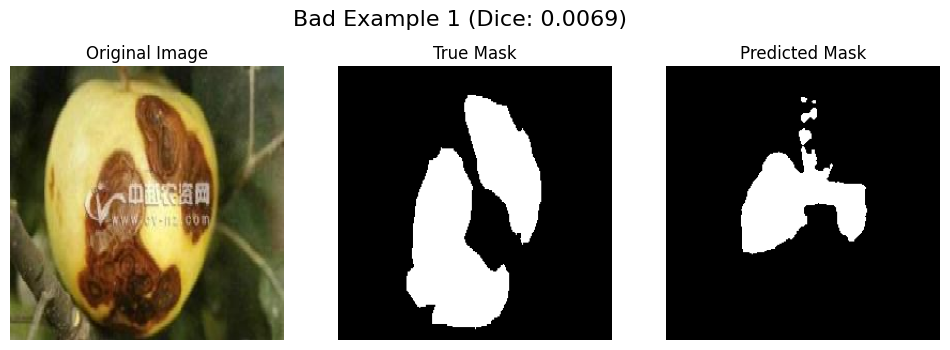

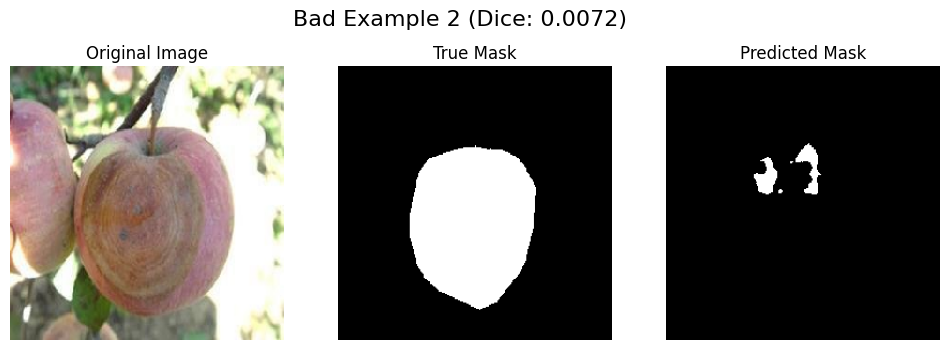

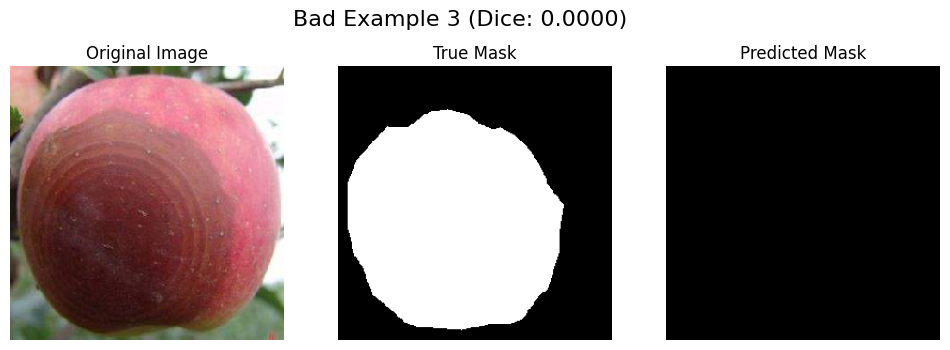

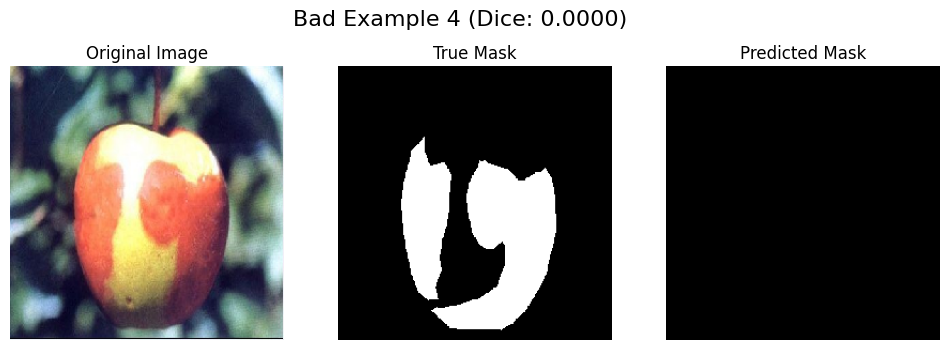

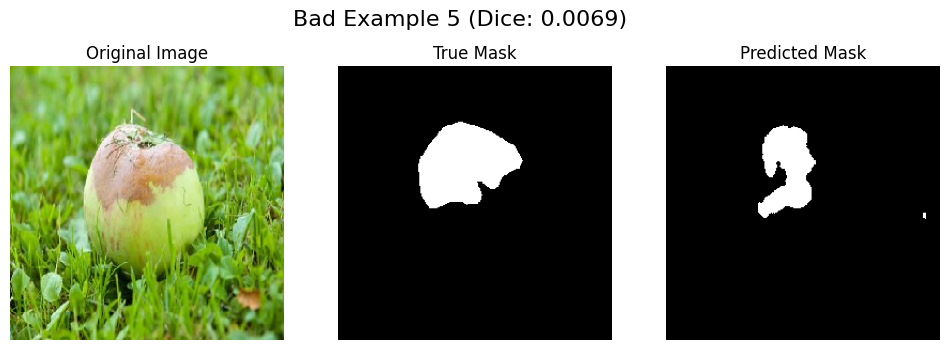

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

test_images = []
for img_file in image_files[:5]:
    img_path = os.path.join(images_test_path, img_file)
    img = load_img(img_path, target_size=(256, 256))
    img = img_to_array(img) / 255.0
    test_images.append(img)

test_images = np.array(test_images)


test_masks = []
for mask_file in mask_files[:5]:
    mask_path = os.path.join(annotations_test_path, mask_file)
    mask = load_img(mask_path, target_size=(256, 256), color_mode="grayscale")
    mask = img_to_array(mask) / 255.0
    test_masks.append(mask)

test_masks = np.array(test_masks)


predicted_masks = model.predict(test_images)
predicted_masks = (predicted_masks > 0.5).astype(int)


results = []
for i, (true_mask, pred_mask) in enumerate(zip(test_masks, predicted_masks)):
    dice = dice_coefficient(true_mask.flatten(), pred_mask.flatten())
    results.append({"index": i, "dice": dice, "true_mask": true_mask, "pred_mask": pred_mask})


threshold_good = 0.7
threshold_bad = 0.4

good_examples = [res for res in results if res["dice"] >= threshold_good]
bad_examples = [res for res in results if res["dice"] <= threshold_bad]

print("Good Examples:")
for example in good_examples:
    i = example["index"]
    true_mask_reshaped = example["true_mask"][..., 0]
    pred_mask_reshaped = example["pred_mask"][..., 0]
    original_image = load_img(os.path.join(images_test_path, image_files[i]), target_size=(256, 256))

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Good Example {i+1} (Dice: {example['dice']:.4f})", fontsize=16)

    plt.subplot(1, 3, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask_reshaped, cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_reshaped, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()


print("Bad Examples:")
for example in bad_examples:
    i = example["index"]
    true_mask_reshaped = example["true_mask"][..., 0]
    pred_mask_reshaped = example["pred_mask"][..., 0]
    original_image = load_img(os.path.join(images_test_path, image_files[i]), target_size=(256, 256))

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Bad Example {i+1} (Dice: {example['dice']:.4f})", fontsize=16)

    plt.subplot(1, 3, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask_reshaped, cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_reshaped, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

